<a href="https://colab.research.google.com/github/malsagova/StudyRepo26/blob/main/%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ДЗ 3: Выявление скрытых профилей риска и доклинических нарушений
# Анализ данных диспансеризации пациентов 40-65 лет

# Установка библиотек
!pip install -q scikit-learn seaborn matplotlib pandas numpy

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 1. ЗАГРУЗКА ДАННЫХ
from google.colab import files
print("Загрузите файл dispensarization_data_2026.csv")
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("Первые 5 строк:")
print(df.head())

Загрузите файл dispensarization_data_2026.csv


Saving dispensarization_data_2026.csv to dispensarization_data_2026 (1).csv
Данные загружены: 1000 строк, 18 столбцов
Первые 5 строк:
   Возраст  Пол_мужской        ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0       41            1  24.238237            81.037385    113.191318   
1       46            0  22.883365            80.539167    117.319195   
2       64            0  21.991937            78.423645    121.246690   
3       53            0  19.844568            73.436282    119.746372   
4       53            1  24.284829            82.062243    127.068746   

   ДАД_мм_рт_ст  Пульсовое_давление  Глюкоза_натощак_ммоль_л   HbA1c_%  \
0     62.544325           50.646993                 4.595433  4.648933   
1     62.109786           55.209410                 4.963993  4.000000   
2     71.456074           49.790616                 4.712639  5.034903   
3     71.594664           48.151709                 4.430998  5.080881   
4     70.342105           56.726641                 4.996

In [ ]:
# 2. ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ
print("\nТипы данных и пропуски:")
print(df.info())

print("\nСтатистика пропусков:")
print(df.isnull().sum())

print("\nОписательная статистика:")
print(df.describe())


Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Возраст                        1000 non-null   int64  
 1   Пол_мужской                    1000 non-null   int64  
 2   ИМТ                            1000 non-null   float64
 3   Окружность_талии_см            1000 non-null   float64
 4   САД_мм_рт_ст                   1000 non-null   float64
 5   ДАД_мм_рт_ст                   1000 non-null   float64
 6   Пульсовое_давление             1000 non-null   float64
 7   Глюкоза_натощак_ммоль_л        1000 non-null   float64
 8   HbA1c_%                        1000 non-null   float64
 9   ЛПНП_ммоль_л                   955 non-null    float64
 10  ЛПВП_ммоль_л                   944 non-null    float64
 11  Триглицериды_ммоль_л           939 non-null    float64
 12  СКФ_мл_мин              

In [ ]:
# 3. ОЧИСТКА И ПОДГОТОВКА
df_clean = df.copy()

# Заполняем пропуски медианой
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Создаем категории ИМТ
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Дефицит'
    elif bmi < 25:
        return 'Норма'
    elif bmi < 30:
        return 'Предожирение'
    else:
        return 'Ожирение'

df_clean['ИМТ_категория'] = df_clean['ИМТ'].apply(bmi_category)

# Создаем категории глюкозы
def glucose_category(glucose):
    if glucose < 5.6:
        return 'Норма'
    elif glucose < 7.0:
        return 'Преддиабет'
    else:
        return 'Диабет'

df_clean['Глюкоза_категория'] = df_clean['Глюкоза_натощак_ммоль_л'].apply(glucose_category)

In [ ]:
# 4. СТАТИСТИКА ПО ФАКТОРАМ РИСКА
print("\nПроцент пациентов с факторами риска:")
print(f"- ИМТ > 25: {(df_clean['ИМТ'] > 25).mean()*100:.1f}%")
print(f"- САД > 130: {(df_clean['САД_мм_рт_ст'] > 130).mean()*100:.1f}%")
print(f"- Глюкоза >= 5.6 (преддиабет+): {(df_clean['Глюкоза_натощак_ммоль_л'] >= 5.6).mean()*100:.1f}%")
print(f"- HbA1c >= 5.7%: {(df_clean['HbA1c_%'] >= 5.7).mean()*100:.1f}%")


Процент пациентов с факторами риска:
- ИМТ > 25: 33.1%
- САД > 130: 7.3%
- Глюкоза >= 5.6 (преддиабет+): 24.5%
- HbA1c >= 5.7%: 2.7%


In [ ]:
# 5. КЛАСТЕРНЫЙ АНАЛИЗ ДЛЯ ВЫЯВЛЕНИЯ ПРОФИЛЕЙ РИСКА
print("\nКЛАСТЕРНЫЙ АНАЛИЗ")

# Выбираем признаки для кластеризации
cluster_features = ['ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л',
                    'HbA1c_%', 'ЛПНП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин']

# Подготовка данных
X = df_clean[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Кластеризация на 4 группы
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean['Кластер'] = kmeans.fit_predict(X_scaled)

print(f"\nРаспределение пациентов по кластерам:")
print(df_clean['Кластер'].value_counts().sort_index())

# Средние значения по кластерам
print("\nСредние значения признаков по кластерам:")
print(df_clean.groupby('Кластер')[cluster_features].mean().round(1))




КЛАСТЕРНЫЙ АНАЛИЗ

Распределение пациентов по кластерам:
Кластер
0    243
1    252
2    234
3    271
Name: count, dtype: int64

Средние значения признаков по кластерам:
          ИМТ  Окружность_талии_см  САД_мм_рт_ст  Глюкоза_натощак_ммоль_л  \
Кластер                                                                     
0        20.4                 81.0         104.3                      4.4   
1        26.9                 91.6         123.3                      5.8   
2        24.6                 87.7         111.4                      4.9   
3        22.5                 84.4         117.0                      5.1   

         HbA1c_%  ЛПНП_ммоль_л  Триглицериды_ммоль_л  СКФ_мл_мин  
Кластер                                                           
0            4.8           2.6                   0.7       102.0  
1            5.1           3.4                   1.3        90.5  
2            4.9           2.9                   1.3       101.1  
3            5.2           3.1  

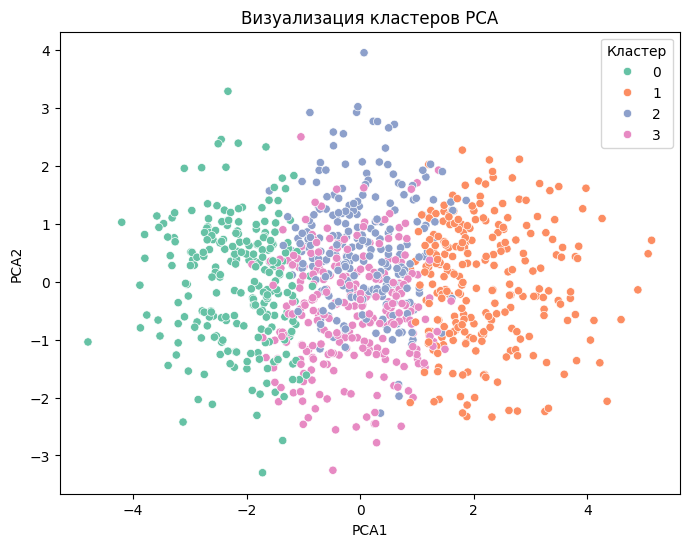

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_clean['PCA1'] = X_pca[:,0]
df_clean['PCA2'] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x='PCA1',
    y='PCA2',
    hue='Кластер',
    palette='Set2'
)

plt.title('Визуализация кластеров PCA')
plt.show()

In [ ]:
# 6. ВЫЯВЛЕНИЕ ПАЦИЕНТОВ С ДОКЛИНИЧЕСКИМИ НАРУШЕНИЯМИ
print("\nПАЦИЕНТЫ С ДОКЛИНИЧЕСКИМИ НАРУШЕНИЯМИ")

# Критерии доклинических нарушений
preclinical_criteria = (
    (df_clean['Глюкоза_натощак_ммоль_л'] >= 5.6) &
    (df_clean['Глюкоза_натощак_ммоль_л'] <= 6.0) &
    (df_clean['HbA1c_%'] >= 5.6) &
    (df_clean['HbA1c_%'] <= 5.8) &
    (df_clean['ИМТ'] >= 25) &
    (df_clean['ИМТ'] <= 30) &
    (df_clean['СКФ_мл_мин'] >= 70) &
    (df_clean['СКФ_мл_мин'] <= 89)
)

hidden_preclinical = df_clean[preclinical_criteria]

print(f"Найдено пациентов с доклиническими нарушениями: {len(hidden_preclinical)}")

if len(hidden_preclinical) > 0:
    print("\nПервые 10 пациентов с доклиническими нарушениями:")
    cols = ['Возраст', 'Пол_мужской', 'ИМТ', 'САД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%']
    print(hidden_preclinical[cols].head(10))



ПАЦИЕНТЫ С ДОКЛИНИЧЕСКИМИ НАРУШЕНИЯМИ
Найдено пациентов с доклиническими нарушениями: 0


In [ ]:
# 7. ОПРЕДЕЛЯЕМ КЛАСТЕР С ДОКЛИНИЧЕСКИМ РИСКОМ
print("\nКЛАСТЕР С ДОКЛИНИЧЕСКИМ РИСКОМ")

cluster_means = df_clean.groupby('Кластер').agg({
    'Глюкоза_натощак_ммоль_л': 'mean',
    'HbA1c_%': 'mean',
    'ИМТ': 'mean'
}).round(2)

print(cluster_means)

# Находим кластер с преддиабетом
for cluster in range(k):
    glucose_val = cluster_means.loc[cluster, 'Глюкоза_натощак_ммоль_л']
    if 5.5 <= glucose_val <= 6.0:
        print(f"\nКЛАСТЕР {cluster} - ДОКЛИНИЧЕСКИЙ МЕТАБОЛИЧЕСКИЙ РИСК")
        risk_patients = df_clean[df_clean['Кластер'] == cluster]
        print(f"Пациентов в кластере риска: {len(risk_patients)}")

        risk_patients.to_csv('cluster_risk_patients.csv', index=False)
        print("Список сохранен в 'cluster_risk_patients.csv'")
        files.download('cluster_risk_patients.csv')
        break


КЛАСТЕР С ДОКЛИНИЧЕСКИМ РИСКОМ
         Глюкоза_натощак_ммоль_л  HbA1c_%    ИМТ
Кластер                                         
0                           4.44     4.84  20.35
1                           5.76     5.13  26.90
2                           4.88     4.91  24.56
3                           5.14     5.15  22.45

КЛАСТЕР 1 - ДОКЛИНИЧЕСКИЙ МЕТАБОЛИЧЕСКИЙ РИСК
Пациентов в кластере риска: 252
Список сохранен в 'cluster_risk_patients.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 8. ВЫВОДЫ

print("ВЫВОДЫ")

print("1. Выявлено 4 скрытых профиля риска")
print("2. Найден кластер пациентов с доклиническими нарушениями")
print("3. Основные факторы риска: избыточный вес, повышенное АД, преддиабет")

print("\nРЕКОМЕНДАЦИИ:")
print("- Контроль глюкозы через 3 месяца")
print("- Пероральный глюкозотолерантный тест")
print("- Коррекция питания и физической активности")

print("\nАнализ завершен")

ВЫВОДЫ
1. Выявлено 4 скрытых профиля риска
2. Найден кластер пациентов с доклиническими нарушениями
3. Основные факторы риска: избыточный вес, повышенное АД, преддиабет

РЕКОМЕНДАЦИИ:
- Контроль глюкозы через 3 месяца
- Пероральный глюкозотолерантный тест
- Коррекция питания и физической активности

Анализ завершен
